# Market Impact and Liquidity in Backtests

**Execution environment**: local `uv run` on CPU.

Market impact is not a fixed cost; it depends on how large an order is
relative to the liquidity available to absorb it. This notebook makes that
concrete on **real US equity data**: it runs the *same* momentum strategy
with the *same* dollar order across stocks spanning five orders of magnitude
in daily volume, from a mega-cap to a micro-cap. The square-root impact model
can have modest effects on a liquid name and outsized effects on a thin one.
This explains why small-cap strategies that look good on paper may not scale
and motivates the liquidity-aware execution policies of Section 21.4.

**Learning Objectives**:
- Express market impact as a function of order size relative to daily volume
- Compare how the same order erodes returns on liquid and thin stocks
- Quantify how often a profitable strategy flips to a loss once realistic
  impact is applied, by liquidity
- Understand why impact motivates adaptive execution (Section 21.4)

**Book Reference**: Chapter 21, Sections 21.4 (Optimal Execution) and 21.8 (Sim-to-Real Gap)

**Prerequisites**: `optimal_execution_ppo`.

In [1]:
"""Market Impact and Liquidity in Backtests - how the same order erodes returns differently across the liquidity spectrum."""

import json
import warnings
from datetime import datetime
from typing import Any

import numpy as np
import plotly.graph_objects as go
import polars as pl
from IPython.display import Markdown, display
from ml4t.backtest import BacktestConfig, DataFeed, Engine, ExecutionMode, Strategy
from ml4t.backtest.broker import Broker
from ml4t.backtest.execution.impact import NoImpact, SquareRootImpact
from plotly.subplots import make_subplots

from data import load_us_equities
from utils.paths import REPO_ROOT, get_output_dir
from utils.reproducibility import set_global_seeds
from utils.style import COLORS

warnings.filterwarnings("ignore", category=FutureWarning)

In [2]:
OUTPUT_DIR = get_output_dir(21, "backtest_with_impact")

In [3]:
START_DATE = "2010-01-01"
END_DATE = "2016-12-31"
FORMATION_END_DATE = "2012-12-31"
EVALUATION_START_DATE = "2013-01-01"
LOOKBACK = 21
BOOK_USD = 5_000_000
IMPACT_COEFFICIENTS = [0.0, 0.1, 0.3, 0.6]
GROSS_MIN = 0.3
COHORT_SAMPLE = 60
SEED = 42
EXPORT_RESULTS = False

In [4]:
# Coerce papermill-injected strings ("true"/"false") to bool; no-op for native bools.
EXPORT_RESULTS = str(EXPORT_RESULTS).strip().lower() in ("true", "1", "yes")

## Configuration

In [5]:
set_global_seeds(SEED)
rng = np.random.default_rng(SEED)

## Load Real US Equity Data

We load daily bars for the broad US equity universe and use the
split- and dividend-**adjusted** OHLCV series, so corporate actions do not
create artificial jumps in the momentum signal. Dollar volume
(price $\times$ volume) is invariant to splits and serves as our liquidity
measure throughout.

In [6]:
def load_adjusted_equities(start: str, end: str) -> pl.DataFrame:
    """Load daily US equities and return adjusted OHLCV under canonical column names."""
    raw = load_us_equities(start_date=start, end_date=end).sort(["symbol", "timestamp"])
    return raw.select(
        "symbol",
        "timestamp",
        pl.col("adj_open").alias("open"),
        pl.col("adj_high").alias("high"),
        pl.col("adj_low").alias("low"),
        pl.col("adj_close").alias("close"),
        pl.col("adj_volume").alias("volume"),
    ).drop_nulls()

In [7]:
prices = load_adjusted_equities(START_DATE, END_DATE)
formation_prices = prices.filter(pl.col("timestamp") <= pl.lit(FORMATION_END_DATE).str.to_date())
evaluation_prices = prices.filter(
    pl.col("timestamp") >= pl.lit(EVALUATION_START_DATE).str.to_date()
)
assert formation_prices["timestamp"].max() < evaluation_prices["timestamp"].min()
print(
    f"Loaded {prices.height:,} daily bars for {prices['symbol'].n_unique():,} symbols "
    f"({prices['timestamp'].min()} to {prices['timestamp'].max()})"
)

Loaded 5,059,822 daily bars for 3,186 symbols (2010-01-04 to 2016-12-30)


## Measure Liquidity Ex Ante

To avoid look-ahead in stock selection and impact calibration, we estimate
each name's liquidity and volatility only through `FORMATION_END_DATE`.
Reported backtests begin at `EVALUATION_START_DATE`.

In [8]:
def formation_statistics(prices: pl.DataFrame) -> pl.DataFrame:
    """Liquidity and volatility estimated only from the formation window."""
    return (
        prices.with_columns(
            (pl.col("close") * pl.col("volume")).alias("dollar_volume"),
            pl.col("close").pct_change().over("symbol").alias("daily_return"),
        )
        .group_by("symbol")
        .agg(
            pl.col("dollar_volume").median().alias("adv_usd"),
            pl.col("daily_return").std().alias("ex_ante_volatility"),
            pl.len().alias("formation_obs"),
        )
        .filter(pl.col("formation_obs") >= 700)
    )

In [9]:
formation_stats = formation_statistics(formation_prices)
liquidity = formation_stats
print(f"Symbols with a full formation window: {liquidity.height:,}")
print(
    f"Daily dollar volume spans ${liquidity['adv_usd'].min():,.0f} to "
    f"${liquidity['adv_usd'].max():,.0f} - five orders of magnitude"
)

Symbols with a full formation window: 2,614
Daily dollar volume spans $0 to $6,654,371,100 - five orders of magnitude


## Scope to a Strategy That Works on Paper

The point of the demonstration is what impact does to a strategy that looked
profitable before the evaluation period. We screen on the formation window,
then measure erosion only on later observations. No evaluation outcome enters
candidate selection.

In [10]:
def gross_momentum_return(prices: pl.DataFrame, lookback: int) -> pl.DataFrame:
    """Vectorized gross return of a long-when-positive-momentum signal, per symbol."""
    scored = prices.with_columns(
        pl.col("close").pct_change().over("symbol").alias("ret"),
        (pl.col("close") / pl.col("close").shift(lookback).over("symbol") - 1).alias("momentum"),
    ).with_columns(
        (
            pl.when(pl.col("momentum") > 0).then(1.0).otherwise(0.0).shift(1).over("symbol")
            * pl.col("ret")
        ).alias("strategy_ret")
    )
    return scored.group_by("symbol").agg(
        ((1 + pl.col("strategy_ret").fill_null(0)).product() - 1).alias("gross_return"),
        pl.col("ret").count().alias("n_obs"),
    )

In [11]:
formation_gross = gross_momentum_return(formation_prices, LOOKBACK).filter(pl.col("n_obs") >= 700)
evaluation_coverage = evaluation_prices.group_by("symbol").agg(pl.len().alias("evaluation_obs"))
pool = (
    formation_gross.filter(pl.col("gross_return") > GROSS_MIN)
    .join(formation_stats, on="symbol")
    .sort("adv_usd")
)
coverage_audit = (
    pool.select("symbol")
    .join(evaluation_coverage, on="symbol", how="left")
    .with_columns(pl.col("evaluation_obs").fill_null(0))
)
evaluable_names = coverage_audit.filter(pl.col("evaluation_obs") >= LOOKBACK + 2).height
print(f"Gross-profitable names selected from formation data: {pool.height:,}")
print(
    f"Later evaluation availability: {evaluable_names:,}/{pool.height:,} have at least "
    f"{LOOKBACK + 2} observations; availability does not alter selection"
)

Gross-profitable names selected from formation data: 650
Later evaluation availability: 650/650 have at least 23 observations; availability does not alter selection


## Select a Representative Liquidity Spectrum

From the gross-profitable pool we pick one representative name at each of five
liquidity tiers, defined by percentiles of ex-ante dollar volume. Within each
tier we take the **median** gross-return name, not the best, so the spectrum
is representative rather than cherry-picked.

In [12]:
def select_spectrum(pool: pl.DataFrame) -> pl.DataFrame:
    """Pick the median-gross name in each of five ex-ante liquidity percentile buckets."""
    tiers = [("mega", 0.99), ("large", 0.90), ("mid", 0.65), ("small", 0.30), ("micro", 0.08)]
    adv = pool["adv_usd"]
    rows = []
    for label, q in tiers:
        lo, hi = adv.quantile(max(0.0, q - 0.04)), adv.quantile(min(1.0, q + 0.04))
        bucket = pool.filter((pl.col("adv_usd") >= lo) & (pl.col("adv_usd") <= hi)).sort(
            "gross_return"
        )
        if bucket.height:
            pick = bucket[bucket.height // 2]
            rows.append(
                {
                    "tier": label,
                    "symbol": pick["symbol"][0],
                    "adv_usd": pick["adv_usd"][0],
                    "ex_ante_volatility": pick["ex_ante_volatility"][0],
                }
            )
    return pl.DataFrame(rows)

In [13]:
spectrum = select_spectrum(pool)
assert spectrum.height == 5, (
    f"select_spectrum produced {spectrum.height} tiers; expected 5 "
    "(mega/large/mid/small/micro) - a degenerate pool would silently drop a row."
)
spectrum = (
    spectrum.join(evaluation_coverage, on="symbol", how="left")
    .with_columns(
        pl.col("evaluation_obs").fill_null(0),
        (BOOK_USD / pl.col("adv_usd")).alias("order_participation"),
    )
    .sort("order_participation")
)
assert (spectrum["evaluation_obs"] >= LOOKBACK + 2).all(), (
    "A formation-selected spectrum name lacks enough later observations for evaluation"
)
spectrum

tier,symbol,adv_usd,ex_ante_volatility,evaluation_obs,order_participation
str,str,f64,f64,u32,f64
"""mega""","""PM""",3.1689e8,0.011918,1008,0.015778
"""large""","""FDO""",7.6726e7,0.017661,631,0.065167
"""mid""","""TDG""",1.6415e7,0.017502,1008,0.304599
"""small""","""ELGX""",2832832.5,0.029697,1008,1.765018
"""micro""","""FRM""",519754.5,0.040322,795,9.619926


## The Square-Root Impact Model

The temporary price impact of an order follows the Almgren-Chriss square-root
law, which scales with the square root of the participation rate - the order
size relative to average daily volume:

$$\text{impact} = c \cdot \sigma \cdot \sqrt{\frac{q}{\text{ADV}}} \cdot p$$

where $c$ is an impact coefficient, $\sigma$ the daily volatility, $q$ the
order quantity, $\text{ADV}$ the bar's traded volume, and $p$ the price.
Impact rises with participation, so the same dollar order costs far more in a
thin stock than a liquid one.

## Define the Momentum Strategy

A long-only momentum strategy: hold the stock fully while `LOOKBACK`-day
momentum is positive, otherwise stay in cash. The same strategy and the same
dollar book are applied to every stock - what varies across the spectrum is
liquidity and its formation-period volatility (the impact model uses each
stock's ex-ante $\sigma$ as well as its ADV).

In [14]:
class MomentumStrategy(Strategy):
    """Long-only momentum: fully invested when LOOKBACK-day momentum is positive, else flat."""

    def __init__(self, symbol: str, lookback: int = 21, min_trade_notional: float = 1_000.0):
        self.symbol = symbol
        self.lookback = lookback
        self.min_trade_notional = min_trade_notional
        self.price_history: list[float] = []

    def on_start(self, broker: Any) -> None:
        self.price_history = []

    def on_data(self, timestamp: datetime, data: dict, context: dict, broker: Any) -> None:
        if self.symbol not in data:
            return

        price = data[self.symbol]["close"]
        self.price_history.append(price)
        if len(self.price_history) < self.lookback + 1:
            return

        momentum = (self.price_history[-1] / self.price_history[-self.lookback - 1]) - 1

        current_pos = broker.get_position(self.symbol)
        current_qty = current_pos.quantity if current_pos else 0
        account_value = broker.get_account_value()
        target_qty = (account_value / price) if (price > 0 and momentum > 0) else 0

        order_qty = target_qty - current_qty
        if abs(order_qty) * price > self.min_trade_notional:
            broker.submit_order(self.symbol, order_qty)

## Single-Stock Backtest Runner

Runs the momentum strategy on one stock under a given impact model. The
square-root model uses volatility fixed before the evaluation period.

In [15]:
def run_backtest(
    stock_data: pl.DataFrame,
    symbol: str,
    impact_coef: float,
    book_usd: float,
    ex_ante_volatility: float,
) -> float:
    """Run the momentum backtest on one stock under a square-root impact coefficient."""
    impact_model = (
        NoImpact()
        if impact_coef == 0
        else SquareRootImpact(coefficient=impact_coef, volatility=ex_ante_volatility)
    )

    feed = DataFeed(prices_df=stock_data)
    engine_config = BacktestConfig(
        initial_cash=book_usd,
        commission_rate=0.001,  # 10 bps
        slippage_rate=0.0005,  # 5 bps
        execution_mode=ExecutionMode.NEXT_BAR,
    )
    engine = Engine(feed=feed, strategy=MomentumStrategy(symbol, LOOKBACK), config=engine_config)
    engine.broker = Broker.from_config(engine_config, market_impact_model=impact_model)
    return float(engine.run().equity.total_return)

## Run the Spectrum Under Each Impact Level

For each stock in the liquidity spectrum, run the strategy under no, low,
medium, and high impact. Failures are collected and re-raised rather than
silently treated as zero return.

In [16]:
def run_spectrum(prices: pl.DataFrame, spectrum: pl.DataFrame, book_usd: float) -> pl.DataFrame:
    """Backtest every (stock, impact-coefficient) pair in the liquidity spectrum."""
    rows: list[dict[str, Any]] = []
    errors: list[str] = []
    for tier_row in spectrum.iter_rows(named=True):
        symbol = tier_row["symbol"]
        stock_data = prices.filter(pl.col("symbol") == symbol).sort("timestamp")
        for impact_coef in IMPACT_COEFFICIENTS:
            try:
                ret = run_backtest(
                    stock_data,
                    symbol,
                    impact_coef,
                    book_usd,
                    tier_row["ex_ante_volatility"],
                )
            except Exception as exc:  # noqa: BLE001 - collected and re-raised below
                errors.append(f"{symbol} (coef {impact_coef}): {exc}")
                continue
            rows.append(
                {
                    "tier": tier_row["tier"],
                    "symbol": symbol,
                    "adv_usd": tier_row["adv_usd"],
                    "order_participation": book_usd / tier_row["adv_usd"],
                    "ex_ante_volatility": tier_row["ex_ante_volatility"],
                    "impact_coef": impact_coef,
                    "total_return": ret,
                }
            )
    if errors:
        raise RuntimeError("Spectrum backtest failed:\n" + "\n".join(errors))
    return pl.DataFrame(rows)

In [17]:
spectrum_results = run_spectrum(evaluation_prices, spectrum, BOOK_USD)
spectrum_results

tier,symbol,adv_usd,order_participation,ex_ante_volatility,impact_coef,total_return
str,str,f64,f64,f64,f64,f64
"""mega""","""PM""",3.1689e8,0.015778,0.011918,0.0,-0.201515
"""mega""","""PM""",3.1689e8,0.015778,0.011918,0.1,-0.198647
"""mega""","""PM""",3.1689e8,0.015778,0.011918,0.3,-0.226031
"""mega""","""PM""",3.1689e8,0.015778,0.011918,0.6,-0.249332
"""large""","""FDO""",7.6726e7,0.065167,0.017661,0.0,-0.068921
…,…,…,…,…,…,…
"""small""","""ELGX""",2832832.5,1.765018,0.029697,0.6,-0.779813
"""micro""","""FRM""",519754.5,9.619926,0.040322,0.0,-0.133652
"""micro""","""FRM""",519754.5,9.619926,0.040322,0.1,-0.535403


## Returns and Erosion Across the Spectrum

Pivot the spectrum into net return by tier and impact level, and compute the
erosion at the strongest impact assumption - the no-impact return minus the
high-impact return. The erosion is pure impact cost: the only thing that
changes between the two runs is the impact model.

In [18]:
def spectrum_summary(spectrum_results: pl.DataFrame) -> pl.DataFrame:
    """Net return by tier and impact level, plus high-impact erosion vs the no-impact baseline."""
    max_coef = max(IMPACT_COEFFICIENTS)
    wide = spectrum_results.pivot(
        values="total_return", index=["tier", "symbol", "order_participation"], on="impact_coef"
    ).sort("order_participation")
    return wide.with_columns((pl.col("0.0") - pl.col(str(max_coef))).alias("erosion_high"))

In [19]:
summary = spectrum_summary(spectrum_results)
summary

tier,symbol,order_participation,0.0,0.1,0.3,0.6,erosion_high
str,str,f64,f64,f64,f64,f64,f64
"""mega""","""PM""",0.015778,-0.201515,-0.198647,-0.226031,-0.249332,0.047817
"""large""","""FDO""",0.065167,-0.068921,-0.085859,-0.118478,-0.16434,0.095419
"""mid""","""TDG""",0.304599,0.222346,0.172494,0.081301,-0.036911,0.259257
"""small""","""ELGX""",1.765018,-0.565592,-0.618331,-0.698964,-0.779813,0.214221
"""micro""","""FRM""",9.619926,-0.133652,-0.535403,-0.805623,-0.91837,0.784719


## How Often Does Impact Flip a Winner Into a Loser?

A single spectrum is illustrative; the effect should hold across the whole
universe. We sample gross-profitable names from a liquid group (orders under
10% of daily volume) and a thin group (orders over 100% of daily volume), run
each with no impact and with high impact, and count how many profitable names
turn into losers once impact is applied.

In [20]:
def flip_rate(
    prices: pl.DataFrame, candidates: pl.DataFrame, book_usd: float, n_sample: int
) -> dict:
    """Winner flips after formation-only sampling, with later data attrition reported."""
    take = min(n_sample, candidates.height)
    idx = sorted(rng.choice(candidates.height, size=take, replace=False).tolist())
    sample = candidates[idx]
    flips, n_valid, n_evaluable = 0, 0, 0
    high_coef = max(IMPACT_COEFFICIENTS)
    for row in sample.iter_rows(named=True):
        stock_data = prices.filter(pl.col("symbol") == row["symbol"]).sort("timestamp")
        if stock_data.height < LOOKBACK + 2:
            continue
        n_evaluable += 1
        no_impact = run_backtest(
            stock_data,
            row["symbol"],
            0.0,
            book_usd,
            row["ex_ante_volatility"],
        )
        high_impact = run_backtest(
            stock_data,
            row["symbol"],
            high_coef,
            book_usd,
            row["ex_ante_volatility"],
        )
        if no_impact > 0:
            n_valid += 1
            flips += int(high_impact < 0)
    return {
        "sampled": take,
        "evaluable": n_evaluable,
        "attrition": take - n_evaluable,
        "n": n_valid,
        "flips": flips,
        "flip_rate": flips / n_valid if n_valid else float("nan"),
    }

In [21]:
pool_part = pool.with_columns((BOOK_USD / pl.col("adv_usd")).alias("order_participation"))
liquid_group = pool_part.filter(pl.col("order_participation") < 0.10)
thin_group = pool_part.filter(pl.col("order_participation") > 1.0)
assert not liquid_group.is_empty(), "liquid_group is empty after participation filter"
assert not thin_group.is_empty(), "thin_group is empty after participation filter"

liquid_flip = flip_rate(evaluation_prices, liquid_group, BOOK_USD, COHORT_SAMPLE)
thin_flip = flip_rate(evaluation_prices, thin_group, BOOK_USD, COHORT_SAMPLE)
print(
    f"Liquid names (order < 10% of ADV): {liquid_flip['flips']}/{liquid_flip['n']} "
    f"evaluation winners flipped negative ({liquid_flip['flip_rate']:.0%}); "
    f"later-data attrition {liquid_flip['attrition']}/{liquid_flip['sampled']}"
)
print(
    f"Thin names (order > 100% of ADV): {thin_flip['flips']}/{thin_flip['n']} "
    f"evaluation winners flipped negative ({thin_flip['flip_rate']:.0%}); "
    f"later-data attrition {thin_flip['attrition']}/{thin_flip['sampled']}"
)

Liquid names (order < 10% of ADV): 7/28 evaluation winners flipped negative (25%); later-data attrition 0/60
Thin names (order > 100% of ADV): 33/36 evaluation winners flipped negative (92%); later-data attrition 0/60


## Visualize Impact Across the Liquidity Spectrum

### Net Return vs Liquidity

Left panel: net return for each stock against its order's participation rate
(log scale), one line per impact level. Right panel: high-impact erosion
against participation. The cross-section need not be monotonic because each
name has a different trading path and turnover, even under one impact model.

In [22]:
IMPACT_STYLES = {
    0.0: dict(color=COLORS["blue"], dash="solid", symbol="circle", name="No Impact"),
    0.1: dict(color=COLORS["slate"], dash="dash", symbol="square", name="Low Impact"),
    0.3: dict(color=COLORS["amber"], dash="dot", symbol="diamond", name="Medium Impact"),
    0.6: dict(color=COLORS["negative"], dash="dashdot", symbol="x", name="High Impact"),
}

Each impact coefficient receives a consistent line, marker, and hover label
so the left panel can be read without relying on color alone.

In [23]:
def add_impact_return_traces(fig: go.Figure, spectrum_results: pl.DataFrame) -> None:
    """Add net-return traces ordered by participation rate."""
    for impact_coef in sorted(spectrum_results["impact_coef"].unique().to_list()):
        subset = spectrum_results.filter(pl.col("impact_coef") == impact_coef).sort(
            "order_participation"
        )
        style = IMPACT_STYLES[impact_coef]
        fig.add_trace(
            go.Scatter(
                x=(subset["order_participation"] * 100).to_list(),
                y=(subset["total_return"] * 100).to_list(),
                mode="lines+markers",
                name=style["name"],
                line=dict(color=style["color"], dash=style["dash"], width=2),
                marker=dict(color=style["color"], symbol=style["symbol"], size=8),
                hovertemplate="Order: %{x:.1f}% of ADV<br>Net return: %{y:.1f}%",
            ),
            row=1,
            col=1,
        )

The completed two-panel figure pairs absolute net returns with the high-impact
erosion relative to the no-impact counterfactual.

In [24]:
def add_erosion_trace(fig: go.Figure, summary: pl.DataFrame) -> None:
    """Add the high-impact erosion trace to the right panel."""
    fig.add_trace(
        go.Scatter(
            x=(summary["order_participation"] * 100).to_list(),
            y=(summary["erosion_high"] * 100).to_list(),
            mode="lines+markers",
            line=dict(color=COLORS["negative"], width=2),
            marker=dict(color=COLORS["negative"], symbol="circle", size=8),
            showlegend=False,
            hovertemplate="Order: %{x:.1f}% of ADV<br>Erosion: %{y:.1f} pp",
        ),
        row=1,
        col=2,
    )

The final assembly uses logarithmic participation axes so five liquidity
orders of magnitude remain legible without implying a linear relationship.

In [25]:
def plot_impact_spectrum(spectrum_results: pl.DataFrame, summary: pl.DataFrame) -> go.Figure:
    thinnest = summary.sort("order_participation").row(-1, named=True)
    fig = make_subplots(
        rows=1,
        cols=2,
        subplot_titles=(
            "Net Return vs Order Participation",
            "Impact Erosion vs Order Participation",
        ),
        horizontal_spacing=0.13,
    )
    add_impact_return_traces(fig, spectrum_results)
    add_erosion_trace(fig, summary)
    fig.update_xaxes(title_text="Order as % of Daily Volume (log)", type="log", row=1, col=1)
    fig.update_xaxes(title_text="Order as % of Daily Volume (log)", type="log", row=1, col=2)
    fig.update_yaxes(title_text="Net Total Return (%)", row=1, col=1)
    fig.update_yaxes(title_text="High-Impact Erosion (pp)", row=1, col=2)
    fig.add_hline(
        y=0,
        line=dict(color=COLORS["neutral"], width=1, dash="dot"),
        row=1,
        col=1,
    )
    fig.update_layout(
        title=(
            f"High impact erodes the thinnest selected name by "
            f"{thinnest['erosion_high'] * 100:.0f} percentage points"
        ),
        height=420,
        width=1000,
    )
    return fig

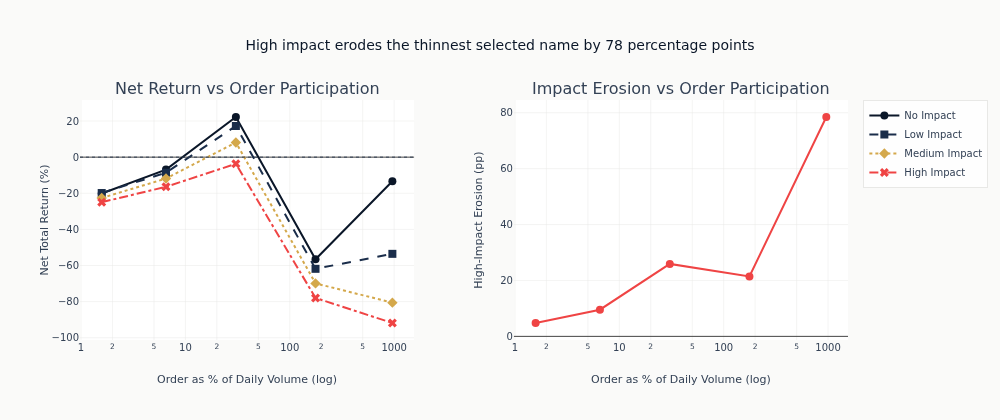

In [26]:
fig = plot_impact_spectrum(spectrum_results, summary)
fig.show()

In [27]:
if EXPORT_RESULTS:
    OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
    spectrum_results.write_parquet(OUTPUT_DIR / "impact_spectrum.parquet")
    summary.write_parquet(OUTPUT_DIR / "impact_summary.parquet")
    flip_df = pl.DataFrame(
        [
            {"group": "liquid_lt_10pct_adv", **liquid_flip},
            {"group": "thin_gt_100pct_adv", **thin_flip},
        ]
    )
    flip_df.write_parquet(OUTPUT_DIR / "impact_flip_rates.parquet")
    try:
        rel = OUTPUT_DIR.relative_to(REPO_ROOT)
    except ValueError:
        rel = OUTPUT_DIR
    print(f"Results saved to {rel}")

## Key Findings

In [28]:
mega = summary.sort("order_participation").row(0, named=True)
micro = summary.sort("order_participation").row(-1, named=True)
high = str(max(IMPACT_COEFFICIENTS))
print("Same strategy and order, different liquidity exposure:")
print(
    f"  {mega['tier']:5s} {mega['symbol']:6s}: order {mega['order_participation'] * 100:.1f}% of ADV - "
    f"no-impact {mega['0.0'] * 100:+.1f}%, high-impact {mega[high] * 100:+.1f}% "
    f"(erosion {mega['erosion_high'] * 100:.0f} pp)"
)
print(
    f"  {micro['tier']:5s} {micro['symbol']:6s}: order {micro['order_participation'] * 100:.0f}% of ADV - "
    f"no-impact {micro['0.0'] * 100:+.1f}%, high-impact {micro[high] * 100:+.1f}% "
    f"(erosion {micro['erosion_high'] * 100:.0f} pp)"
)
print(
    f"\nUnder high impact, {thin_flip['flip_rate']:.0%} of thin-stock winners flip to losers, "
    f"versus {liquid_flip['flip_rate']:.0%} of liquid-stock winners."
)

Same strategy and order, different liquidity exposure:
  mega  PM    : order 1.6% of ADV - no-impact -20.2%, high-impact -24.9% (erosion 5 pp)
  micro FRM   : order 962% of ADV - no-impact -13.4%, high-impact -91.8% (erosion 78 pp)

Under high impact, 92% of thin-stock winners flip to losers, versus 25% of liquid-stock winners.


In [29]:
display(
    Markdown(
        f"""
## Key Takeaways

The same {BOOK_USD:,.0f} USD order is {mega["order_participation"]:.1%} of formation-period ADV for
the most liquid selected name and {micro["order_participation"]:.0%} for the thinnest. Under the
high-impact assumption, their evaluation-period return erosion is {mega["erosion_high"]:.1%} and
{micro["erosion_high"]:.1%}, respectively. Impact is therefore relative to liquidity, not merely to
the dollar order.

Each formation cohort samples {thin_flip["sampled"]} names. Of these, {thin_flip["n"]} thin names
and {liquid_flip["n"]} liquid names are no-impact winners during evaluation. High impact flips
{thin_flip["flips"]} of those {thin_flip["n"]} thin winners ({thin_flip["flip_rate"]:.0%}) and
{liquid_flip["flips"]} of those {liquid_flip["n"]} liquid winners
({liquid_flip["flip_rate"]:.0%}) to negative evaluation returns. Later-data attrition is
{thin_flip["attrition"]}/{thin_flip["sampled"]} in the thin sample and
{liquid_flip["attrition"]}/{liquid_flip["sampled"]} in the liquid sample. Selection, liquidity,
volatility, and random sampling are fixed before {EVALUATION_START_DATE}; later availability is
reported after selection and does not alter those inputs.

A static schedule ignores how much available volume it consumes. Section 21.4 shows how execution
policies can condition child-order timing and size on liquidity state.

**Next**: See `optimal_execution_ppo` for adaptive execution in a calibrated simulator.
"""
    )
)


## Key Takeaways

The same 5,000,000 USD order is 1.6% of formation-period ADV for
the most liquid selected name and 962% for the thinnest. Under the
high-impact assumption, their evaluation-period return erosion is 4.8% and
78.5%, respectively. Impact is therefore relative to liquidity, not merely to
the dollar order.

Each formation cohort samples 60 names. Of these, 36 thin names
and 28 liquid names are no-impact winners during evaluation. High impact flips
33 of those 36 thin winners (92%) and
7 of those 28 liquid winners
(25%) to negative evaluation returns. Later-data attrition is
0/60 in the thin sample and
0/60 in the liquid sample. Selection, liquidity,
volatility, and random sampling are fixed before 2013-01-01; later availability is
reported after selection and does not alter those inputs.

A static schedule ignores how much available volume it consumes. Section 21.4 shows how execution
policies can condition child-order timing and size on liquidity state.

**Next**: See `optimal_execution_ppo` for adaptive execution in a calibrated simulator.


## Reproducibility Record

The final machine-readable record binds formation selection, later attrition,
executed results, and the output-derived figure claim for independent review.

In [30]:
completion_record = {
    "formation_pool": pool.height,
    "selected_symbols": spectrum["symbol"].to_list(),
    "selected_evaluation_obs": spectrum["evaluation_obs"].to_list(),
    "summary": summary.to_dicts(),
    "liquid_flip": liquid_flip,
    "thin_flip": thin_flip,
    "figure_title": fig.layout.title.text,
}
print("COMPLETION_RECORD=" + json.dumps(completion_record, sort_keys=True, default=str))

COMPLETION_RECORD={"figure_title": "High impact erodes the thinnest selected name by 78 percentage points", "formation_pool": 650, "liquid_flip": {"attrition": 0, "evaluable": 60, "flip_rate": 0.25, "flips": 7, "n": 28, "sampled": 60}, "selected_evaluation_obs": [1008, 631, 1008, 1008, 795], "selected_symbols": ["PM", "FDO", "TDG", "ELGX", "FRM"], "summary": [{"0.0": -0.20151505676750803, "0.1": -0.19864671828960856, "0.3": -0.22603123946028114, "0.6": -0.24933177164871523, "erosion_high": 0.0478167148812072, "order_participation": 0.015778205536451064, "symbol": "PM", "tier": "mega"}, {"0.0": -0.0689209413243882, "0.1": -0.08585912755107838, "0.3": -0.11847845563284809, "0.6": -0.16433960783559431, "erosion_high": 0.09541866651120612, "order_participation": 0.06516726037521105, "symbol": "FDO", "tier": "large"}, {"0.0": 0.22234597239287623, "0.1": 0.17249438762128744, "0.3": 0.08130103234842934, "0.6": -0.03691143394640439, "erosion_high": 0.2592574063392806, "order_participation": 0.